# EE200 Course Project — Q2: The Midnight Episode
**Mayur (Roll 240643) · Catching the Arrhythmia via template correlation**

Maya teaches the computer one healthy heartbeat, slides it along the Holter
recording, and flags the moment the shape stops matching. Core logic lives in
`src/q2_ecg.py`; this notebook works through parts **(a)–(h)** with every number
**computed**, not eyeballed.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
import numpy as np
import matplotlib.pyplot as plt
import q2_ecg as q2

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})
DATA, FIG = os.path.join("..", "data"), os.path.join("..", "figures")
os.makedirs(FIG, exist_ok=True)

ecg = np.load(os.path.join(DATA, "patient_ecg.npy"))
template = np.load(os.path.join(DATA, "template.npy"))
fs = q2.FS_HZ
print(f"Loaded REAL data: ecg N={ecg.size} samples, template L={template.size} samples, fs={fs} Hz")

Loaded REAL data: ecg N=5000 samples, template L=200 samples, fs=250.0 Hz


## (a) Reading the signal  [0.75%]

(a)(i)  duration = N/fs = 5000/250 = 20.0 s
(a)(ii) heart rate = 60/0.8 = 75 bpm; samples/beat = 0.8*250 = 200
(a)(iii) fundamental frequency f0 = 1/0.8 = 1.250 Hz


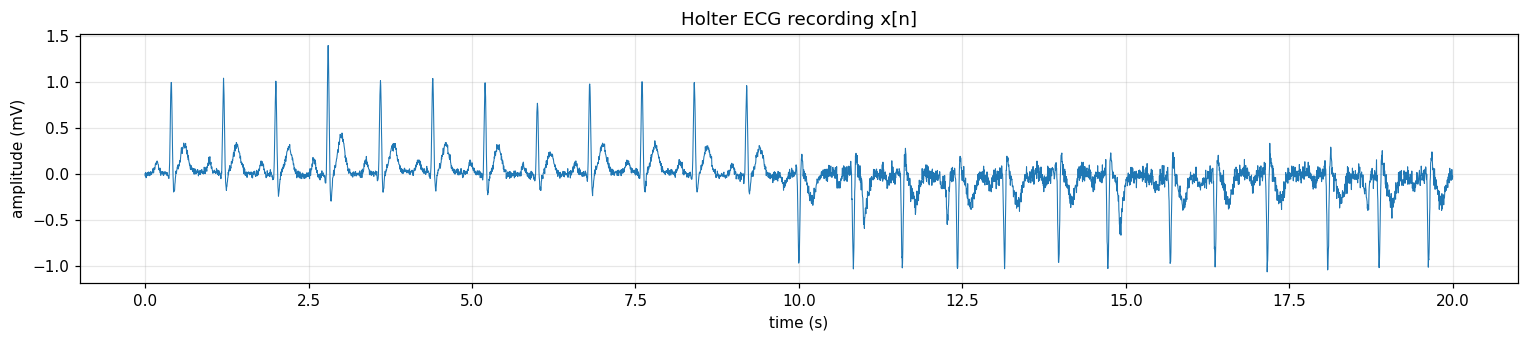

In [2]:
N, L = ecg.size, template.size
duration = N / fs
beat_period_s = 0.8                  # one beat every 0.8 s (given)
samples_per_beat = beat_period_s * fs
hr_bpm = 60 / beat_period_s
f0 = 1 / beat_period_s
print(f"(a)(i)  duration = N/fs = {N}/{fs:.0f} = {duration:.1f} s")
print(f"(a)(ii) heart rate = 60/0.8 = {hr_bpm:.0f} bpm; samples/beat = 0.8*{fs:.0f} = {samples_per_beat:.0f}")
print(f"(a)(iii) fundamental frequency f0 = 1/0.8 = {f0:.3f} Hz")

t = np.arange(N) / fs
plt.figure(figsize=(14, 3.2))
plt.plot(t, ecg, lw=0.7)
plt.xlabel("time (s)"); plt.ylabel("amplitude (mV)"); plt.title("Holter ECG recording x[n]")
plt.tight_layout(); plt.savefig(os.path.join(FIG, "q2_ecg_full.png")); plt.show()

**Answers (a).** (i) 20.0 s. (ii) 75 bpm, 200 samples/beat. (iii) $f_0=1.25$ Hz.

## (b) Healthy heart in the frequency domain  [0.75%]
A (nearly) periodic signal has a **discrete line spectrum**: energy concentrates
at harmonics of $f_0$, not a smooth continuous curve. We confirm this on the
healthy portion.

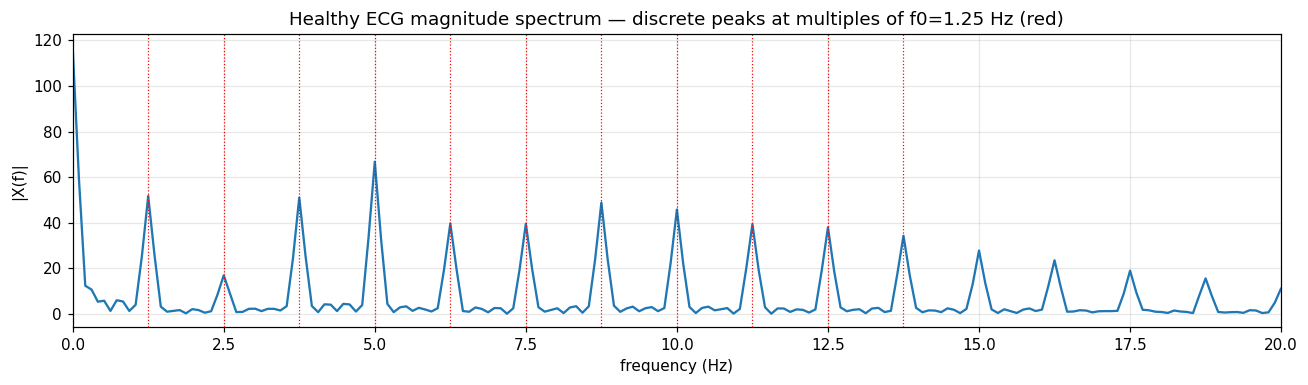

(b)(iii) If HR rises to 150 bpm: period=0.4s -> f0 = 1/0.4 = 2.5 Hz; harmonic spacing (=f0) also DOUBLES.


In [3]:
healthy = ecg[:2400]                          # before the arrhythmia onset (see part g)
X = np.fft.rfft(healthy * np.hanning(healthy.size))
freqs = np.fft.rfftfreq(healthy.size, 1/fs)
plt.figure(figsize=(12, 3.6))
plt.plot(freqs, np.abs(X)); plt.xlim(0, 20)
for k in range(1, 12):
    plt.axvline(k*f0, color="r", ls=":", lw=0.8)
plt.xlabel("frequency (Hz)"); plt.ylabel("|X(f)|")
plt.title("Healthy ECG magnitude spectrum — discrete peaks at multiples of f0=1.25 Hz (red)")
plt.tight_layout(); plt.savefig(os.path.join(FIG, "q2_spectrum.png")); plt.show()
print("(b)(iii) If HR rises to 150 bpm: period=0.4s -> f0 = 1/0.4 =", 1/0.4, "Hz;",
      "harmonic spacing (=f0) also DOUBLES.")

**Answers (b).** (i) Not a smooth curve — a **line spectrum** with peaks at
$f_0,2f_0,3f_0,\dots$ (red lines). (ii) The **QRS** spike drives the
high-frequency content: a narrow, sharp time-domain feature needs broadband
frequency support (time–bandwidth / uncertainty principle), whereas the broad,
smooth P and T waves are inherently low-frequency. (iii) At 150 bpm the period
halves to 0.4 s, so $f_0=2.5$ Hz and the harmonic spacing (which equals $f_0$)
**doubles**.

## (c) Cutting a heartbeat (windowing)  [1.0%]
A rectangular window of width $\approx$ one beat period (200 samples), placed to
bracket a full $\{P,QRS,T\}$ cycle, isolates one clean template.

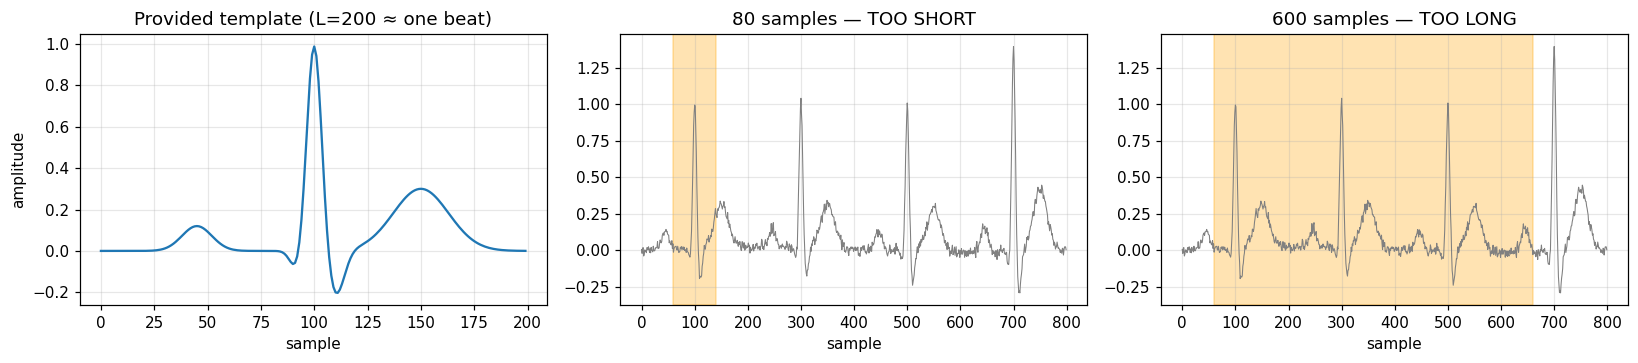

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
ax[0].plot(template); ax[0].set_title(f"Provided template (L={L} ≈ one beat)")
ax[0].set_xlabel("sample"); ax[0].set_ylabel("amplitude")

# Demonstrate the two bad window widths on the recording's first beat region.
seg = ecg[:800]
for w, a, lbl in [(80, ax[1], "80 samples — TOO SHORT"), (600, ax[2], "600 samples — TOO LONG")]:
    a.plot(seg, lw=0.7, color="gray")
    a.axvspan(60, 60+w, color="orange", alpha=0.3)
    a.set_title(lbl); a.set_xlabel("sample")
plt.tight_layout(); plt.savefig(os.path.join(FIG, "q2_windows.png")); plt.show()

**Answers (c).** (i) $\approx$200 samples (one beat period), starting just before
the P wave so it brackets one full $\{P,QRS,T\}$. (ii) **80 samples**: too short —
it slices into the beat, clipping part of the QRS/T, so the template is
incomplete/distorted, and the hard rectangular edges cause spectral leakage.
**600 samples**: too long — it swallows fragments of neighbouring beats,
contaminating the template with adjacent-beat energy. (iii) Same
uncertainty-principle trade-off as STFT windows: a shorter window gives sharper
time localization but poorer frequency resolution and *here* literally risks
cutting through the beat itself, so "as short as possible" is not automatically
best.

## (d) Matching the template (normalized correlation)  [1.5%]
$$\rho(m)=\frac{\sum_k t[k]\,x[m+k]}{\lVert t\rVert\,\lVert x_m\rVert}\in[-1,1]
\quad\text{(Cauchy–Schwarz)}.$$

In [5]:
# Empirical demonstrations of the (d) reasoning.
beat = ecg[600:600+L]                              # a healthy beat
rho_self = q2.normalized_correlation(template, template)
rho_2x   = q2.normalized_correlation(template, 2*template)   # twice as tall, same shape
dot_2x_ratio = np.dot(template, 2*template) / np.dot(template, template)
rho_inv  = q2.normalized_correlation(template, -template)    # inverted beat
print(f"(d)(i)   rho(template, template)          = {rho_self:+.3f}  (perfect match = +1)")
print(f"(d)(ii)  rho(template, 2*template)        = {rho_2x:+.3f}  (UNCHANGED: normalization removes amplitude)")
print(f"         unnormalized dot would scale by  = {dot_2x_ratio:.1f}x  (conflates shape with size)")
print(f"(d)(iii) rho(template, -template)         = {rho_inv:+.3f}  (inverted beat -> ~-1, easy to flag)")

(d)(i)   rho(template, template)          = +1.000  (perfect match = +1)
(d)(ii)  rho(template, 2*template)        = +1.000  (UNCHANGED: normalization removes amplitude)
         unnormalized dot would scale by  = 2.0x  (conflates shape with size)
(d)(iii) rho(template, -template)         = -1.000  (inverted beat -> ~-1, easy to flag)


**Answers (d).** (i) $\rho\in[-1,1]$; $+1$ = near-perfect match. (ii)
Normalization removes sensitivity to amplitude and slow **baseline wander**: a
perfectly-shaped beat twice as tall keeps $\rho=+1$, whereas the *unnormalized*
dot product would roughly **double**, wrongly conflating "right shape" with
"right size". (iii) An inverted beat gives $\rho\approx-1$ — far from the healthy
$\rho\approx+1$, so a simple threshold flags it instantly.

## (e) Onset detection & the spectrogram  [1.5%]

Onset (first beat with rho<0.5): sample 2400  ->  t = 9.60 s  (beat #12)


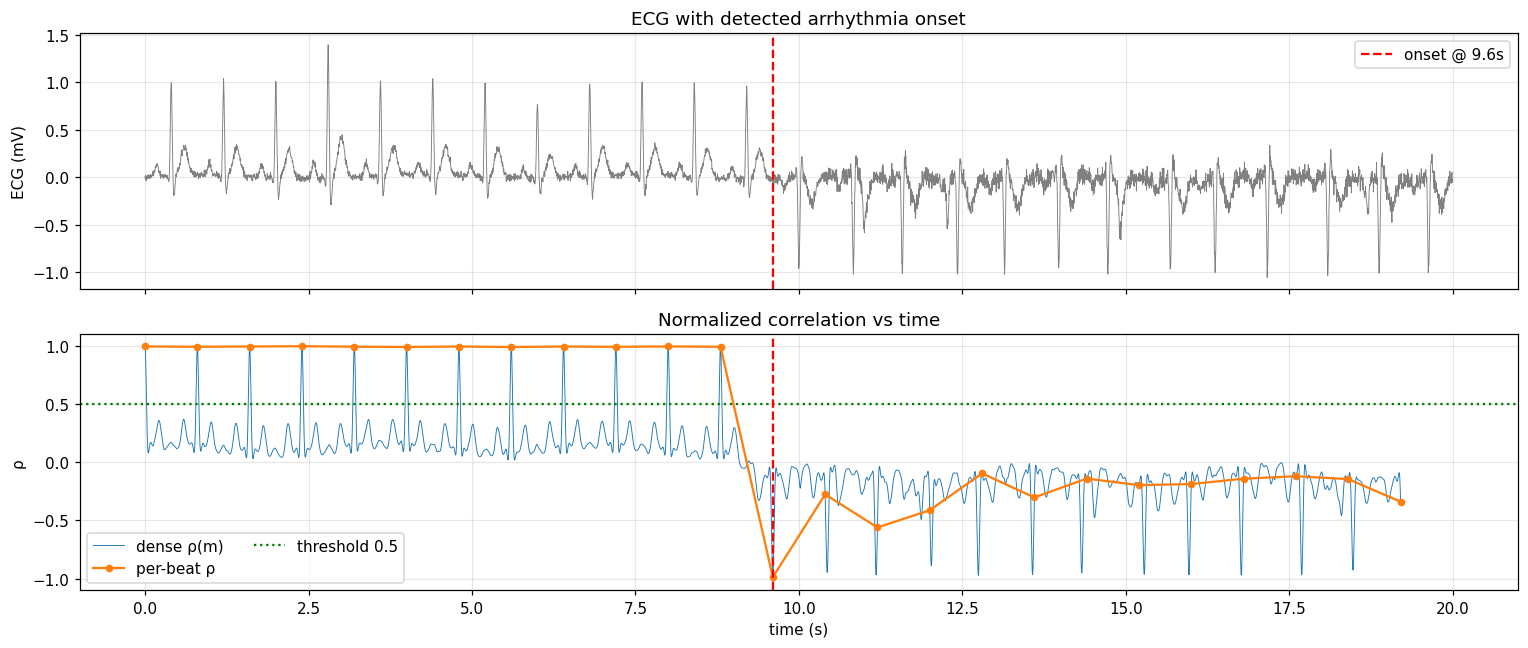

In [6]:
rho_dense = q2.correlation_trace(ecg, template)
starts, beat_scores = q2.beat_scores(ecg, template)
onset = q2.find_onset(ecg, template, threshold=0.5)
print(f"Onset (first beat with rho<0.5): sample {onset}  ->  t = {onset/fs:.2f} s  (beat #{onset//L})")

fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax[0].plot(t, ecg, lw=0.6, color="gray"); ax[0].set_ylabel("ECG (mV)")
ax[0].axvline(onset/fs, color="red", ls="--", label=f"onset @ {onset/fs:.1f}s")
ax[0].set_title("ECG with detected arrhythmia onset"); ax[0].legend(loc="upper right")
ax[1].plot(np.arange(rho_dense.size)/fs, rho_dense, lw=0.6, label="dense ρ(m)")
ax[1].plot(starts/fs, beat_scores, "o-", ms=4, color="C1", label="per-beat ρ")
ax[1].axhline(0.5, color="green", ls=":", label="threshold 0.5")
ax[1].axvline(onset/fs, color="red", ls="--")
ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("ρ"); ax[1].set_ylim(-1.1, 1.1)
ax[1].set_title("Normalized correlation vs time"); ax[1].legend(loc="lower left", ncol=2)
plt.tight_layout(); plt.savefig(os.path.join(FIG, "q2_correlation.png")); plt.show()

**Answers (e).** (i) Rule: declare the onset at the first beat where $\rho$ drops
below a threshold (0.5, as fixed in (g)). Threshold too **high** → false alarms
from normal beat-to-beat variation/noise; too **low** → misses mild but real
morphology changes. (ii) Spectrogram: the **healthy** region shows clean, steady
horizontal harmonic bands at $f_0,2f_0,\dots$; the **arrhythmia** region shows
those bands smearing, breaking, shifting, with irregular new energy. (iii) The
two may disagree on the exact instant because the spectrogram must accumulate
several irregular beats inside its window before the harmonic structure visibly
degrades (smeared/delayed estimate), whereas correlation flags **per beat** —
so trust the **correlation** for the precise onset beat and use the spectrogram
as the corroborating big-picture view.

## (f) Sampling & aliasing  [0.5%]

In [7]:
qrs_bw, fs_low = 40.0, 50.0
print(f"(f)(i)  Nyquist minimum = 2 x {qrs_bw:.0f} Hz = {2*qrs_bw:.0f} Hz")
print(f"(f)(ii) At {fs_low:.0f} Hz (< 80 Hz) QRS content above {fs_low/2:.0f} Hz folds back (aliases),")
print( "        distorting the sharp spike shape -> corrupts the shape-based correlation detector.")
print(f"(f)(iii) Fix: anti-alias low-pass (~{fs_low/2:.0f} Hz cutoff) BEFORE downsampling;")
print( "        unavoidable cost: real fine QRS morphology/sharpness is lost.")

(f)(i)  Nyquist minimum = 2 x 40 Hz = 80 Hz
(f)(ii) At 50 Hz (< 80 Hz) QRS content above 25 Hz folds back (aliases),
        distorting the sharp spike shape -> corrupts the shape-based correlation detector.
(f)(iii) Fix: anti-alias low-pass (~25 Hz cutoff) BEFORE downsampling;
        unavoidable cost: real fine QRS morphology/sharpness is lost.


**Answers (f).** (i) $2\times40=80$ Hz. (ii) At 50 Hz the QRS content above 25 Hz
aliases down into lower frequencies, smearing/distorting the sharp spike or
injecting spurious components — dangerous because the detector relies on
shape correlation, so aliased distortion causes false positives/negatives. (iii)
Fix: an anti-alias low-pass filter (cutoff ~25 Hz) before downsampling; the
unavoidable cost is losing genuine fine QRS diagnostic detail.

## (g) Prototyping the detector — `find_onset`  [1.5%]
Implemented in `src/q2_ecg.py` and imported here. It steps **beat-by-beat**
(stride = `len(template)` = 200), scores each beat by normalized correlation, and
returns the start index of the first beat with $\rho<$ threshold, else $-1$:

```python
def find_onset(ecg_signal, template, threshold=0.5):
    x, t = np.asarray(ecg_signal), np.asarray(template)
    L = t.size
    for m in range(0, x.size - L + 1, L):      # one stride per beat
        if normalized_correlation(t, x[m:m + L]) < threshold:
            return m
    return -1
```

In [8]:
onset = q2.find_onset(ecg, template, 0.5)
print(f"find_onset(ecg, template, 0.5) = {onset}  ->  arrhythmia begins at t = {onset/fs:.2f} s (beat #{onset//L})")
print("Sanity checks:")
print("  threshold=2.0  (above every score) ->", q2.find_onset(ecg, template, 2.0), "(first beat)")
print("  threshold=-2.0 (impossible)        ->", q2.find_onset(ecg, template, -2.0), "(never breached)")

find_onset(ecg, template, 0.5) = 2400  ->  arrhythmia begins at t = 9.60 s (beat #12)
Sanity checks:
  threshold=2.0  (above every score) -> 0 (first beat)
  threshold=-2.0 (impossible)        -> -1 (never breached)


## (h) Visualizing the spectrogram  [0.5%]
**Window-length choice.** Frequency resolution is $\Delta f=f_s/\texttt{nperseg}$.
To resolve the harmonic spacing $f_0=1.25$ Hz we need $\Delta f\lesssim1.25$ Hz,
i.e. $\texttt{nperseg}\gtrsim f_s/f_0 = 250/1.25 = 200$. We pick
**`nperseg = 500`** ($\Delta f = 0.5$ Hz) — comfortably finer than 1.25 Hz — so the
harmonics appear as clean, well-separated horizontal bands in the healthy region.

nperseg=500 -> frequency resolution df = fs/nperseg = 0.50 Hz  (< f0=1.25 Hz, good)


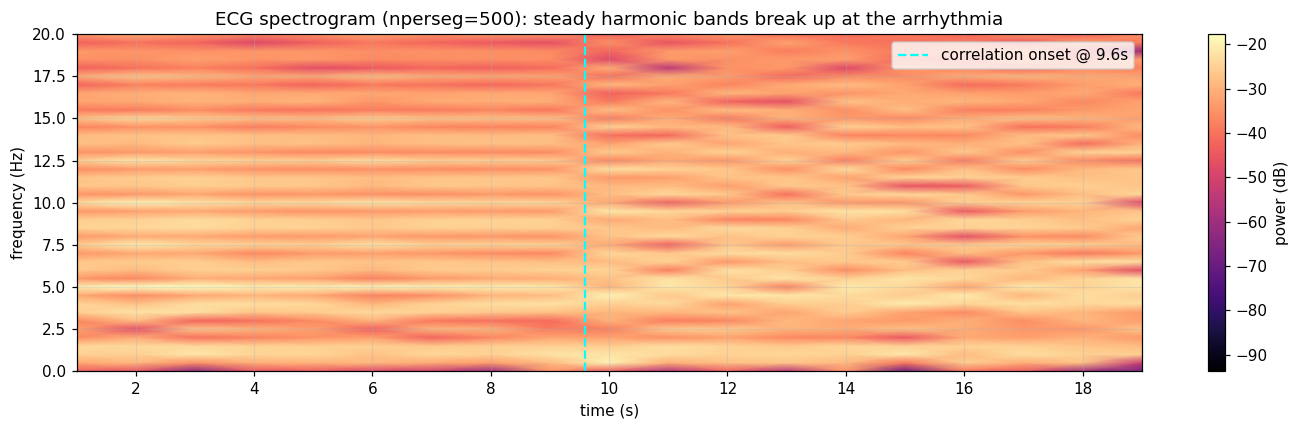

In [9]:
f_sp, t_sp, Sxx = q2.compute_spectrogram(ecg, fs=fs, nperseg=500)
print(f"nperseg=500 -> frequency resolution df = fs/nperseg = {fs/500:.2f} Hz  (< f0=1.25 Hz, good)")
plt.figure(figsize=(13, 4))
plt.pcolormesh(t_sp, f_sp, 10*np.log10(Sxx + 1e-12), shading="gouraud", cmap="magma")
plt.ylim(0, 20)
plt.axvline(onset/fs, color="cyan", ls="--", lw=1.5, label=f"correlation onset @ {onset/fs:.1f}s")
plt.colorbar(label="power (dB)")
plt.xlabel("time (s)"); plt.ylabel("frequency (Hz)")
plt.title("ECG spectrogram (nperseg=500): steady harmonic bands break up at the arrhythmia")
plt.legend(loc="upper right"); plt.tight_layout()
plt.savefig(os.path.join(FIG, "q2_spectrogram.png")); plt.show()

---
## Q2 — Summary
Real Holter data (`patient_ecg.npy`, `template.npy`). Clip = 20 s, 75 bpm, 200
samples/beat, $f_0=1.25$ Hz. Normalized correlation stays $\approx+1$ for the
first 12 beats, then the **arrhythmia onset at $t=9.6$ s (sample 2400)** begins
with an **inverted beat** ($\rho\approx-1$). The spectrogram (nperseg=500)
independently shows the clean harmonic bands disintegrating there. Correlation
pinpoints the exact onset beat; the spectrogram corroborates the big picture.